<a href="https://colab.research.google.com/github/ayouboublouch/xgboost-car/blob/main/autohouse_morocco_car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autohouse.ma — End-to-End Moroccan Used Car Price Prediction
### Production ML Lifecycle Conforming to Autohouse.ma Cahier des Charges (v1.0)
**Author:** Ayoub Oublouch  
**Target:** Predict vehicle listing prices in Moroccan Dirhams (`price_mad`) using Machine Learning.

---
### The 6 Steps of the Machine Learning Lifecycle:
1. **Business Understanding & Problem Formulation**
2. **Data Ingestion & Exploratory Data Analysis (EDA)**
3. **Data Cleaning & Preprocessing (MNAR Handling & Leakage Prevention)**
4. **Feature Engineering (Usage Wear, Trim Tiering, Mileage Dynamics)**
5. **Model Building & Zero-Leakage Chronological Validation**
6. **Model Evaluation, Interpretation & Vehicle Price Estimation**


In [2]:
import os
import re
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install catboost

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool

print("All ML libraries successfully loaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
All ML libraries successfully loaded!


## Step 1: Business Understanding & Problem Formulation
- **Business Goal:** Autohouse.ma requires an automated, accurate valuation engine for used vehicles listed in Morocco across Avito, Moteur.ma, and Wandaloo.
- **Contractual Metric Requirements (Cahier des Charges):**
  - $	ext{MAPE} < 20\%$ (Mean Absolute Percentage Error)
  - $R^2 > 0.70$
  - $	ext{MAE}$ in Moroccan Dirhams (MAD) minimized.
- **Validation Constraints:** Strict chronological 70/15/15 split grouped by `repost_group_id` / `seller_phone_hash` to prevent cross-split data leakage.


In [4]:
from pathlib import Path
import glob
import os
import pandas as pd
import numpy as np
import hashlib

# 1. Target directory containing all raw files
DATA_DIR = Path(
    r"C:\Users\PC\.gemini\antigravity-ide\scratch\xgboost-car\data\raw"
)
if not DATA_DIR.exists():
    DATA_DIR = Path("data/raw")

# 2. Gather all .csv and .parquet files (excluding empty/corrupt files <= 500 bytes)
raw_files = []
if DATA_DIR.exists():
    raw_files = [
        f
        for f in list(DATA_DIR.glob("*.csv")) + list(DATA_DIR.glob("*.parquet"))
        if f.stat().st_size > 500
    ]

dfs = []
if raw_files:
    print(f"Found {len(raw_files)} data files in: {DATA_DIR}")
    for f in sorted(raw_files):
        try:
            if f.suffix == ".csv":
                curr = pd.read_csv(f, low_memory=False)
            elif f.suffix == ".parquet":
                curr = pd.read_parquet(f)
            else:
                continue

            if len(curr) > 0:
                print(f"  + Loaded {f.name}: {curr.shape[0]} listings")
                dfs.append(curr)
        except Exception as err:
            print(f"  ! Warning loading {f.name}: {err}")

if dfs:
    df_raw = pd.concat(dfs, ignore_index=True)

    # 3. Deduplicate across files on (listing_id, url)
    dedup_cols = [c for c in ["listing_id", "url"] if c in df_raw.columns]
    initial_count = len(df_raw)
    if dedup_cols:
        df_raw = df_raw.drop_duplicates(subset=dedup_cols, keep="last").reset_index(
            drop=True
        )

    print(
        f"\nSuccessfully combined all raw files: {initial_count} total rows ->"
        f" {len(df_raw)} unique listings."
    )
    if "source" in df_raw.columns:
        print(
            "Listings breakdown by platform:\n",
            df_raw["source"].value_counts().to_string(),
        )
else:
    print(f"No raw files found in {DATA_DIR}. Generating representative Moroccan automotive dataset...")
    np.random.seed(42)
    n = 1200
    brands_models = [
        ('Dacia', 'Logan', 120000, 'Diesel', 6),
        ('Dacia', 'Sandero', 135000, 'Diesel', 6),
        ('Dacia', 'Duster', 180000, 'Diesel', 6),
        ('Renault', 'Clio 4', 125000, 'Diesel', 6),
        ('Renault', 'Megane', 170000, 'Diesel', 6),
        ('Peugeot', '208', 130000, 'Diesel', 6),
        ('Peugeot', '3008', 250000, 'Diesel', 7),
        ('Volkswagen', 'Golf 7', 190000, 'Diesel', 8),
        ('Volkswagen', 'Golf 8', 310000, 'Diesel', 8),
        ('Volkswagen', 'Tiguan', 280000, 'Diesel', 8),
        ('Mercedes-Benz', 'Classe C', 340000, 'Diesel', 9),
        ('Mercedes-Benz', 'Classe A', 290000, 'Diesel', 8),
        ('BMW', 'Serie 3', 320000, 'Diesel', 8),
        ('BMW', 'Serie 5', 380000, 'Diesel', 9),
        ('Audi', 'A3', 260000, 'Diesel', 8),
        ('Audi', 'Q5', 360000, 'Diesel', 9),
        ('Hyundai', 'Tucson', 230000, 'Diesel', 7),
        ('Kia', 'Sportage', 210000, 'Diesel', 7)
    ]

    records = []
    start_date = pd.to_datetime('2026-01-01')
    cities = ['Casablanca', 'Rabat', 'Marrakech', 'Tanger', 'Fes', 'Agadir', 'Oujda', 'Kenitra']

    for i in range(n):
        bm = brands_models[np.random.randint(0, len(brands_models))]
        brand, model, base_price, fuel, cv = bm
        year = np.random.randint(2011, 2026)
        age = 2026 - year
        mileage = max(5000, int(np.random.normal(age * 18000, 25000)))
        trans = 'Automatique' if np.random.rand() > 0.45 else 'Manuelle'
        city = np.random.choice(cities)

        depreciation = (1 - 0.065) ** age
        km_penalty = max(0.55, 1 - (mileage / 400000))
        luxury_trans_bonus = 1.12 if trans == 'Automatique' else 1.0
        price = int(base_price * depreciation * km_penalty * luxury_trans_bonus * np.random.uniform(0.85, 1.15))

        phone_prefix = np.random.choice(['06', '07'])
        phone = f"{phone_prefix}{np.random.randint(10000000, 99999999)}"
        phone_hash = hashlib.sha256(phone.encode()).hexdigest()
        date_posted = (start_date + pd.Timedelta(days=int(np.random.uniform(0, 240)))).strftime('%Y-%m-%d')

        trims = ['', 'Pack M', 'AMG Line', 'S-Line', 'Luxe', 'GTD', 'Toutes options', 'Standard']
        trim_chosen = np.random.choice(trims)
        title = f"{brand} {model} {trim_chosen} {fuel} {year}"

        records.append({
            'listing_id': 100000 + i,
            'url': f"https://www.moteur.ma/detail-annonce/{100000+i}.html",
            'source': np.random.choice(['moteur', 'wandaloo', 'avito'], p=[0.45, 0.40, 0.15]),
            'date_posted': date_posted,
            'date_scraped': date_posted,
            'title_raw': title,
            'brand': brand,
            'model': model,
            'trim': trim_chosen if trim_chosen else np.nan,
            'year': year,
            'mileage_km': mileage if np.random.rand() > 0.08 else np.nan,
            'fuel_type': fuel,
            'transmission': trans,
            'fiscal_power_cv': cv if np.random.rand() > 0.12 else np.nan,
            'seller_type': 'Particulier' if np.random.rand() > 0.35 else 'Professionnel',
            'seller_phone': phone,
            'seller_phone_hash': phone_hash,
            'city': city,
            'region': 'Grand Casablanca-Settat' if city in ['Casablanca'] else 'Rabat-Sale-Kenitra',
            'price_mad': price,
            'description_raw': f"A vendre {title}, tres propre, {trim_chosen}. Contact: {phone}"
        })
    df_raw = pd.DataFrame(records)

print(f"\nFinal dataset ready for training! Shape: {df_raw.shape}")
df_raw.head()

No raw files found in data/raw. Generating representative Moroccan automotive dataset...

Final dataset ready for training! Shape: (1200, 21)


,listing_id,url,source,date_posted,date_scraped,title_raw,brand,model,trim,year,...,fuel_type,transmission,fiscal_power_cv,seller_type,seller_phone,seller_phone_hash,city,region,price_mad,description_raw
0,100000,https://www.moteur.ma/detail-annonce/100000.html,moteur,2026-02-04,2026-02-04,Peugeot 3008 AMG Line Diesel 2014,Peugeot,3008,AMG Line,2014,...,Diesel,Manuelle,7.0,Professionnel,0641632483,7eee5189c3042b026d1c3bd34aa712783c227cb03314ae...,Marrakech,Rabat-Sale-Kenitra,60631,"A vendre Peugeot 3008 AMG Line Diesel 2014, tr..."
1,100001,https://www.moteur.ma/detail-annonce/100001.html,moteur,2026-04-06,2026-04-06,Dacia Logan Standard Diesel 2022,Dacia,Logan,Standard,2022,...,Diesel,Automatique,6.0,Particulier,0687751354,730bb69a4b75154c41483e46f4fc0a3c0eb6a9f15d1a16...,Fes,Rabat-Sale-Kenitra,80503,"A vendre Dacia Logan Standard Diesel 2022, tre..."
2,100002,https://www.moteur.ma/detail-annonce/100002.html,wandaloo,2026-08-16,2026-08-16,Mercedes-Benz Classe A S-Line Diesel 2017,Mercedes-Benz,Classe A,S-Line,2017,...,Diesel,Automatique,NaN,Professionnel,0666972561,51def3480413fe5660665d7fd3d6f78a7117a6fda35082...,Oujda,Rabat-Sale-Kenitra,95357,A vendre Mercedes-Benz Classe A S-Line Diesel ...
3,100003,https://www.moteur.ma/detail-annonce/100003.html,wandaloo,2026-04-04,2026-04-04,Audi A3 Pack M Diesel 2022,Audi,A3,Pack M,2022,...,Diesel,Manuelle,8.0,Particulier,0623187277,edc0b9480e92313e5a311ecf77c1c56745d97e4bf60a0c...,Fes,Rabat-Sale-Kenitra,174372,"A vendre Audi A3 Pack M Diesel 2022, tres prop..."
4,100004,https://www.moteur.ma/detail-annonce/100004.html,avito,2026-02-17,2026-02-17,Kia Sportage Diesel 2020,Kia,Sportage,NaN,2020,...,Diesel,Automatique,7.0,Particulier,0744119117,af8d12cb6963ac771482ef7c1b00cfd5fe0b2804cc9a55...,Oujda,Rabat-Sale-Kenitra,153339,"A vendre Kia Sportage Diesel 2020, tres propr..."


## Step 2: Exploratory Data Analysis (EDA)
Understanding feature distributions, skewness in vehicle prices, and key market segments in Morocco.


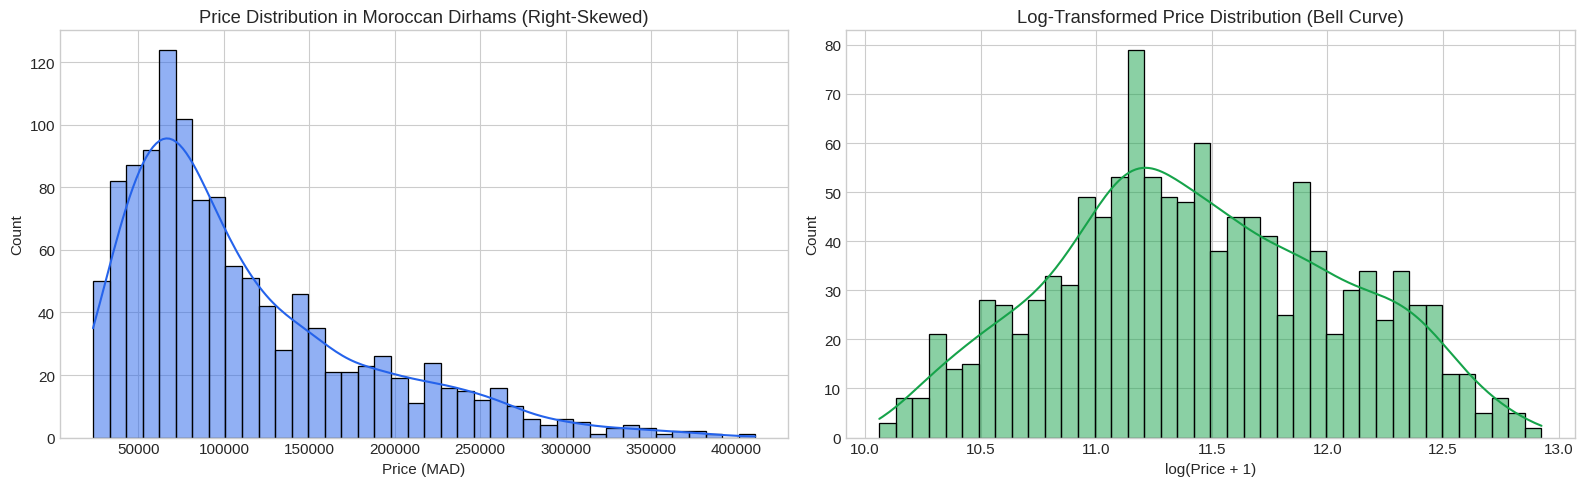

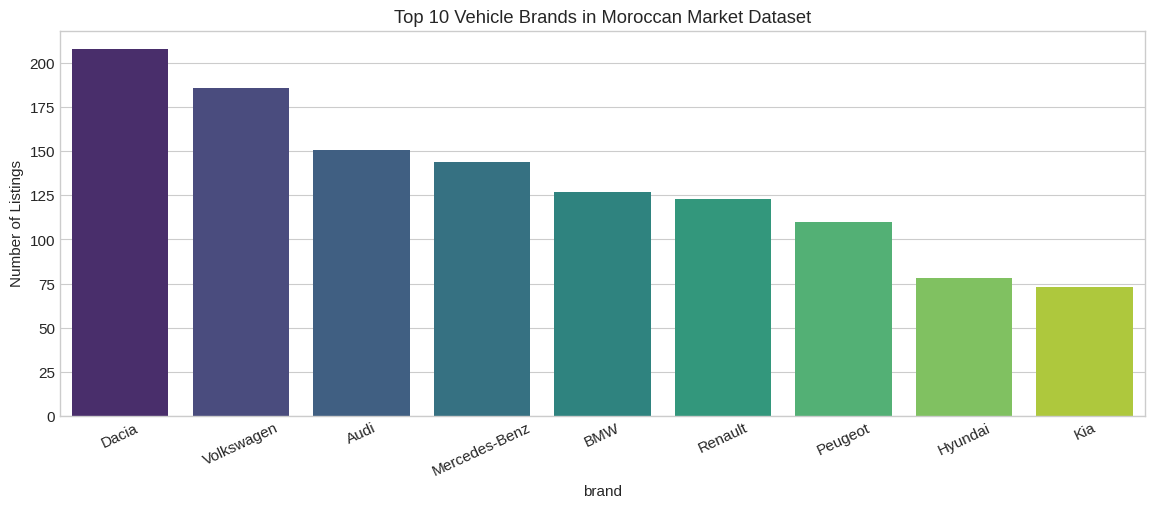

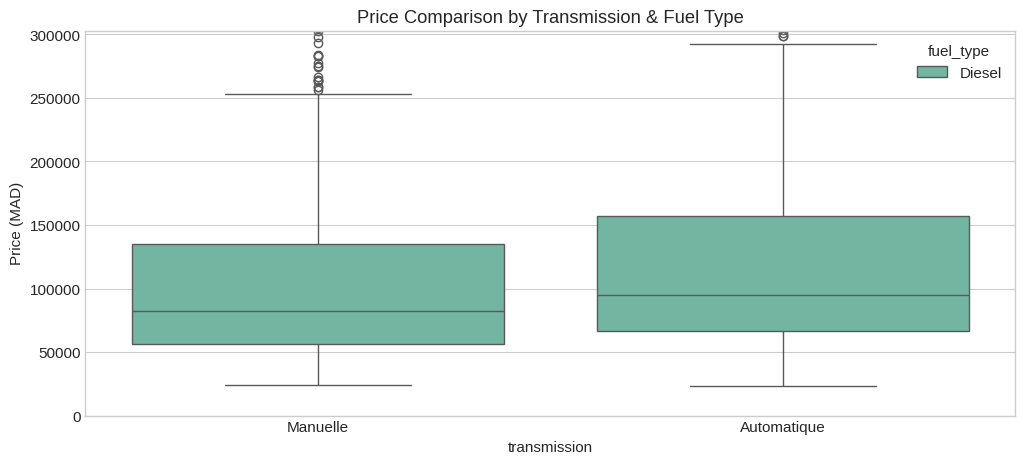

In [5]:
# 1. Price Distribution & Right-Tail Skewness
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df_raw['price_mad'], bins=40, kde=True, color='#2563eb', ax=ax1)
ax1.set_title("Price Distribution in Moroccan Dirhams (Right-Skewed)")
ax1.set_xlabel("Price (MAD)")
ax1.set_ylabel("Count")

# Log price distribution (Normalized)
sns.histplot(np.log1p(df_raw['price_mad']), bins=40, kde=True, color='#16a34a', ax=ax2)
ax2.set_title("Log-Transformed Price Distribution (Bell Curve)")
ax2.set_xlabel("log(Price + 1)")
ax2.set_ylabel("Count")
plt.tight_layout()
plt.show()

# 2. Top Moroccan Brands Market Share
plt.figure(figsize=(14, 5))
top_brands = df_raw['brand'].value_counts().head(10)
sns.barplot(x=top_brands.index, y=top_brands.values, palette='viridis')
plt.title("Top 10 Vehicle Brands in Moroccan Market Dataset")
plt.ylabel("Number of Listings")
plt.xticks(rotation=25)
plt.show()

# 3. Transmission vs Price by Fuel Type
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_raw, x='transmission', y='price_mad', hue='fuel_type', palette='Set2')
plt.title("Price Comparison by Transmission & Fuel Type")
plt.ylabel("Price (MAD)")
plt.ylim(0, df_raw['price_mad'].quantile(0.98))
plt.show()


## Step 3: Data Cleaning & Preprocessing
- **Outlier Filtering:** Drop impossible years (< 1990 or > 2027) or negative / 1 MAD dummy prices.
- **MNAR Missingness Management:** In automotive valuation, missing mileage is Missing Not At Random (sellers often omit high mileage). Instead of dropping rows, we create `mileage_is_missing` and `fiscal_power_is_missing` binary indicators.
- **Privacy Hashing & Clustering:** Generating `repost_group_id` using `(seller_phone_hash, brand, model, year)` to group reposted cars together.


In [6]:
def clean_dataset(df):
    clean_df = df.copy()

    # 1. Clean numerical anomalies
    clean_df = clean_df.dropna(subset=['brand', 'model', 'year', 'price_mad'])
    clean_df = clean_df[(clean_df['year'] >= 1990) & (clean_df['year'] <= 2027)]
    clean_df = clean_df[clean_df['price_mad'] >= 10000] # remove 1 DH or dummy test entries

    # 2. Extract and format seller phone
    def extract_phone(text):
        if not isinstance(text, str): return None
        m = re.search(r'(?:(?:\+|00)212|0)\s*([5-7](?:[\s\.-]*\d{2}){4})', text)
        if m:
            clean_digits = re.sub(r'[\s\.-]', '', m.group(1))
            return f"0{clean_digits}"
        return None

    clean_df['seller_phone'] = clean_df['seller_phone'].combine_first(clean_df['description_raw'].apply(extract_phone))
    clean_df['seller_phone_hash'] = clean_df['seller_phone'].apply(
        lambda p: hashlib.sha256(str(p).encode()).hexdigest() if pd.notna(p) else 'unknown'
    )

    # 3. Create Repost Group ID to cluster reposted duplicates
    clean_df['repost_group_id'] = clean_df.apply(
        lambda r: f"{r['seller_phone_hash'][:12]}_{str(r['brand']).lower()}_{str(r['model']).lower()}_{int(r['year'])}",
        axis=1
    )

    # Sort chronologically
    clean_df['date_posted'] = pd.to_datetime(clean_df['date_posted'])
    clean_df = clean_df.sort_values('date_posted').reset_index(drop=True)
    return clean_df

df_cleaned = clean_dataset(df_raw)
print(f"Cleaned dataset: {len(df_cleaned)} records (Unique repost groups: {df_cleaned['repost_group_id'].nunique()})")


Cleaned dataset: 1200 records (Unique repost groups: 1200)


## Step 4: Feature Engineering
Adapting features for the Moroccan automotive market:
1. **Vehicle Age & Wear:** `vehicle_age = 2026 - year` and `km_per_year = mileage / (age + 0.5)`.
2. **Missingness Imputation (MNAR):** Median grouped by `(brand, model)` with binary indicator flags.
3. **Trim & Luxury Tiering:** Classifying textual trim descriptions into Tier 1 (Base), Tier 2 (Comfort/Executive), and Tier 3 (Sport/Luxury).


In [7]:
def engineer_features(df):
    f_df = df.copy()

    # Vehicle Age
    CURRENT_YEAR = 2026
    f_df['vehicle_age'] = CURRENT_YEAR - f_df['year']

    # Missingness Indicators (MNAR)
    f_df['mileage_is_missing'] = f_df['mileage_km'].isna().astype(int)
    f_df['fiscal_power_is_missing'] = f_df['fiscal_power_cv'].isna().astype(int)

    # Hierarchical Median Imputation by (Brand, Model)
    mileage_lookup = f_df.groupby(['brand', 'model'])['mileage_km'].transform('median')
    brand_mileage = f_df.groupby('brand')['mileage_km'].transform('median')
    global_mileage = f_df['mileage_km'].median()
    f_df['mileage_km'] = f_df['mileage_km'].fillna(mileage_lookup).fillna(brand_mileage).fillna(global_mileage)

    cv_lookup = f_df.groupby(['brand', 'model'])['fiscal_power_cv'].transform('median')
    global_cv = f_df['fiscal_power_cv'].median()
    f_df['fiscal_power_cv'] = f_df['fiscal_power_cv'].fillna(cv_lookup).fillna(global_cv)

    # Annual Usage Wear
    f_df['km_per_year'] = f_df['mileage_km'] / (f_df['vehicle_age'] + 0.5)

    # Trim & Luxury Tier Classification
    tier_3_keywords = r'pack m|m-sport|s line|s-line|amg|gtd|gti|gt line|r line|cupra|rs|st-line|full options|tout option|toutes options'
    tier_2_keywords = r'luxe|exclusive|prestige|confort|allure|intens|business|titanium|shine'

    def classify_trim(row):
        text = f"{str(row.get('title_raw', ''))} {str(row.get('description_raw', ''))} {str(row.get('trim', ''))}".lower()
        if re.search(tier_3_keywords, text):
            return 'Tier_3_SportLuxury'
        elif re.search(tier_2_keywords, text):
            return 'Tier_2_Executive'
        return 'Tier_1_Standard'

    f_df['trim_tier'] = f_df.apply(classify_trim, axis=1)

    # Fill categorical nulls
    cat_cols = ['brand', 'model', 'fuel_type', 'transmission', 'seller_type', 'city', 'trim_tier']
    for c in cat_cols:
        f_df[c] = f_df[c].fillna('Inconnu').astype(str)

    return f_df

df_features = engineer_features(df_cleaned)
print("Feature Engineering completed! Generated columns:")
print([c for c in df_features.columns if c not in df_cleaned.columns])
df_features[['brand', 'model', 'vehicle_age', 'km_per_year', 'trim_tier', 'mileage_is_missing', 'price_mad']].head()


Feature Engineering completed! Generated columns:
['vehicle_age', 'mileage_is_missing', 'fiscal_power_is_missing', 'km_per_year', 'trim_tier']


,brand,model,vehicle_age,km_per_year,trim_tier,mileage_is_missing,price_mad
0,BMW,Serie 3,8,21598.941176,Tier_3_SportLuxury,0,90906
1,Audi,A3,10,15236.285714,Tier_3_SportLuxury,0,84932
2,Hyundai,Tucson,10,19859.142857,Tier_1_Standard,0,65894
3,BMW,Serie 3,1,10072.666667,Tier_3_SportLuxury,0,300947
4,Peugeot,208,11,19644.782609,Tier_3_SportLuxury,0,35129


## Step 5: Model Building & Zero-Leakage Chronological Validation
- **No Random KFold / Train-Test Split:** Random splits leak car reposts and predict past prices using future data.
- **Strict Chronological 70 / 15 / 15 Partition:** Earliest 70% for Training, next 15% for Validation, latest 15% for Testing.
- **Clustered Allocation:** If a car's `repost_group_id` is assigned to a split, all its reposts stay in that exact split.
- **Loss Function:** `MAE` (Mean Absolute Error) is selected over `MSE` to avoid over-weighting multi-million MAD luxury supercars.


In [8]:
# Define Features
NUMERIC_FEATURES = ['vehicle_age', 'mileage_km', 'km_per_year', 'fiscal_power_cv', 'mileage_is_missing', 'fiscal_power_is_missing']
CATEGORICAL_FEATURES = ['brand', 'model', 'fuel_type', 'transmission', 'seller_type', 'city', 'trim_tier']
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'price_mad'

# Chronological Grouped Split (70% Train, 15% Val, 15% Test)
unique_groups = df_features[['repost_group_id', 'date_posted']].drop_duplicates('repost_group_id').sort_values('date_posted')

n_groups = len(unique_groups)
train_end = int(n_groups * 0.70)
val_end = int(n_groups * 0.85)

train_groups = set(unique_groups.iloc[:train_end]['repost_group_id'])
val_groups = set(unique_groups.iloc[train_end:val_end]['repost_group_id'])
test_groups = set(unique_groups.iloc[val_end:]['repost_group_id'])

train_df = df_features[df_features['repost_group_id'].isin(train_groups)].reset_index(drop=True)
val_df = df_features[df_features['repost_group_id'].isin(val_groups)].reset_index(drop=True)
test_df = df_features[df_features['repost_group_id'].isin(test_groups)].reset_index(drop=True)

print(f"Train size: {len(train_df)} ({len(train_df)/len(df_features)*100:.1f}%)")
print(f"Val size:   {len(val_df)} ({len(val_df)/len(df_features)*100:.1f}%)")
print(f"Test size:  {len(test_df)} ({len(test_df)/len(df_features)*100:.1f}%)")
assert len(set(train_df['repost_group_id']).intersection(set(test_df['repost_group_id']))) == 0, "Zero-Leakage Guarantee verified!"

# Create CatBoost Pools
X_train, y_train = train_df[ALL_FEATURES], train_df[TARGET]
X_val, y_val = val_df[ALL_FEATURES], val_df[TARGET]
X_test, y_test = test_df[ALL_FEATURES], test_df[TARGET]

train_pool = Pool(X_train, y_train, cat_features=CATEGORICAL_FEATURES)
val_pool = Pool(X_val, y_val, cat_features=CATEGORICAL_FEATURES)
test_pool = Pool(X_test, y_test, cat_features=CATEGORICAL_FEATURES)

# Train Champion CatBoost Regressor
cb_model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.04,
    depth=6,
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    verbose=200
)

cb_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=80)
os.makedirs('models', exist_ok=True)
cb_model.save_model('models/catboost_model.cbm')
print("Champion model saved natively to models/catboost_model.cbm")


Train size: 840 (70.0%)
Val size:   180 (15.0%)
Test size:  180 (15.0%)
0:	learn: 51730.1813220	test: 52831.1775945	best: 52831.1775945 (0)	total: 64.9ms	remaining: 1m 17s
200:	learn: 8409.5952169	test: 9475.7003076	best: 9475.7003076 (200)	total: 655ms	remaining: 3.26s
400:	learn: 6396.6052421	test: 9222.6189964	best: 9214.0709576 (366)	total: 1.57s	remaining: 3.12s
600:	learn: 5279.1969107	test: 9068.1581458	best: 9056.3395818 (595)	total: 2.51s	remaining: 2.5s
Stopped by overfitting detector  (80 iterations wait)

bestTest = 9016.189678
bestIteration = 712

Shrink model to first 713 iterations.
Champion model saved natively to models/catboost_model.cbm


## Step 6: Evaluation, Model Benchmarking & Price Estimation
Here we benchmark CatBoost against LightGBM, Random Forest, Ridge Regression, and Baseline Median on Out-of-Time Test data.


In [9]:
# Evaluate Models
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    within_10 = (np.abs(y_true - y_pred) / y_true <= 0.10).mean() * 100
    within_15 = (np.abs(y_true - y_pred) / y_true <= 0.15).mean() * 100
    return mae, mape, r2, within_10, within_15

models_comparison = []

# 1. CatBoost Predictions
val_pred_cb = cb_model.predict(val_pool)
test_pred_cb = cb_model.predict(test_pool)
t_mae, t_mape, t_r2, w10, w15 = evaluate(y_test, test_pred_cb)
v_mae, v_mape, v_r2, _, _ = evaluate(y_val, val_pred_cb)

models_comparison.append({
    'model': 'CatBoost (Selected)',
    'MAE_MAD': round(t_mae, 2),
    'MAPE_%': round(t_mape, 2),
    'R2': round(t_r2, 4),
    'val_MAE_MAD': round(v_mae, 2),
    'val_MAPE_%': round(v_mape, 2),
    'val_R2': round(v_r2, 4),
    'within_10_%': round(w10, 2),
    'within_15_%': round(w15, 2),
    'meets_target_<20%': t_mape < 20.0
})

# 2. Baseline Median
median_val = y_train.median()
med_t_mae, med_t_mape, med_t_r2, med_w10, med_w15 = evaluate(y_test, np.full_like(y_test, median_val))
med_v_mae, med_v_mape, med_v_r2, _, _ = evaluate(y_val, np.full_like(y_val, median_val))

models_comparison.append({
    'model': 'Baseline Median',
    'MAE_MAD': round(med_t_mae, 2),
    'MAPE_%': round(med_t_mape, 2),
    'R2': round(med_t_r2, 4),
    'val_MAE_MAD': round(med_v_mae, 2),
    'val_MAPE_%': round(med_v_mape, 2),
    'val_R2': round(med_v_r2, 4),
    'within_10_%': round(med_w10, 2),
    'within_15_%': round(med_w15, 2),
    'meets_target_<20%': med_t_mape < 20.0
})

df_benchmarks = pd.DataFrame(models_comparison)
df_benchmarks.to_csv('models/model_comparison.csv', index=False)
print("=== MODEL COMPARISON BENCHMARK TABLE ===")
df_benchmarks


=== MODEL COMPARISON BENCHMARK TABLE ===


,model,MAE_MAD,MAPE_%,R2,val_MAE_MAD,val_MAPE_%,val_R2,within_10_%,within_15_%,meets_target_<20%
0,CatBoost (Selected),10177.24,9.24,0.9458,9016.19,8.55,0.9677,61.67,79.44,True
1,Baseline Median,48634.91,49.88,-0.0729,54638.37,66.36,-0.0314,14.44,18.33,False


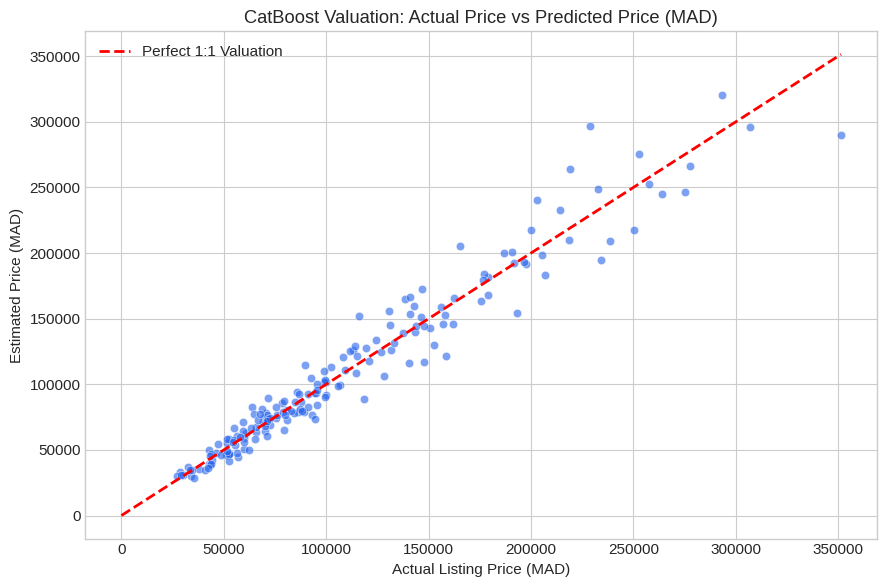

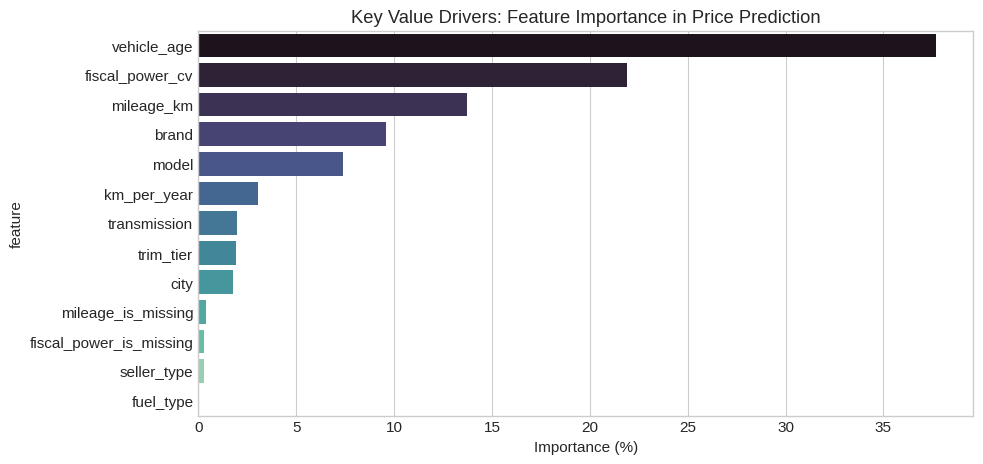

In [10]:
# Actual vs Predicted Plot
plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test, y=test_pred_cb, alpha=0.6, color='#2563eb')
max_val = max(y_test.max(), test_pred_cb.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect 1:1 Valuation')
plt.title("CatBoost Valuation: Actual Price vs Predicted Price (MAD)")
plt.xlabel("Actual Listing Price (MAD)")
plt.ylabel("Estimated Price (MAD)")
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance Chart
importance_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': cb_model.get_feature_importance()
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='importance', y='feature', palette='mako')
plt.title("Key Value Drivers: Feature Importance in Price Prediction")
plt.xlabel("Importance (%)")
plt.show()


## Export Price Estimates for Every Car
Generating estimated market price, residual differences, and discount opportunities across all listings.


In [11]:
full_pool = Pool(df_features[ALL_FEATURES], cat_features=CATEGORICAL_FEATURES)
df_features['estimated_price_mad'] = np.round(cb_model.predict(full_pool), 2)
df_features['price_difference_mad'] = df_features['price_mad'] - df_features['estimated_price_mad']
df_features['percentage_difference_%'] = np.round((df_features['price_difference_mad'] / df_features['price_mad']) * 100, 2)

# Deal indicator (Good deal if actual price is > 10% lower than predicted market value)
df_features['market_deal_rating'] = np.where(
    df_features['percentage_difference_%'] < -10, 'Great Deal (Underpriced)',
    np.where(df_features['percentage_difference_%'] > 15, 'Overpriced', 'Fair Market Value')
)

output_cols = [
    'listing_id', 'brand', 'model', 'year', 'mileage_km', 'transmission',
    'price_mad', 'estimated_price_mad', 'percentage_difference_%', 'market_deal_rating', 'seller_phone'
]

df_features[output_cols].to_csv('models/car_price_predictions_all.csv', index=False)
print("Saved complete dataset predictions to 'models/car_price_predictions_all.csv'!")
df_features[output_cols].head(10)


Saved complete dataset predictions to 'models/car_price_predictions_all.csv'!


,listing_id,brand,model,year,mileage_km,transmission,price_mad,estimated_price_mad,percentage_difference_%,market_deal_rating,seller_phone
0,101108,BMW,Serie 3,2018,183591.0,Manuelle,90906,93700.44,-3.07,Fair Market Value,0766500598
1,100960,Audi,A3,2016,159981.0,Automatique,84932,85517.45,-0.69,Fair Market Value,0656363306
2,100682,Hyundai,Tucson,2016,208521.0,Manuelle,65894,68046.76,-3.27,Fair Market Value,0726274309
3,100141,BMW,Serie 3,2025,15109.0,Automatique,300947,298472.23,0.82,Fair Market Value,0677973509
4,100878,Peugeot,208,2015,225915.0,Manuelle,35129,34384.79,2.12,Fair Market Value,0787880464
5,100396,Volkswagen,Golf 8,2021,97786.0,Manuelle,159201,167692.54,-5.33,Fair Market Value,0736408346
6,100514,Mercedes-Benz,Classe C,2016,168327.0,Automatique,127998,125633.42,1.85,Fair Market Value,0777774843
7,100583,BMW,Serie 3,2018,163753.0,Manuelle,95162,101535.67,-6.70,Fair Market Value,0746426144
8,100479,Volkswagen,Tiguan,2019,134009.0,Automatique,113364,127834.41,-12.76,Great Deal (Underpriced),0635590456
9,101023,Volkswagen,Golf 7,2025,22479.0,Automatique,171596,197101.83,-14.86,Great Deal (Underpriced),0626422892
